STEP 1: ENABLE GPU
✓ GPU enabled

STEP 2: LOAD DATA
Found 5216 files belonging to 2 classes.
Found 16 files belonging to 2 classes.
Found 624 files belonging to 2 classes.
✓ Data loaded!

STEP 3: CHECK BALANCE
Normal: 1341 images
Pneumonia: 3875 images

Normal: 25.7%
Pneumonia: 74.3%

STEP 4: DATA AUGMENTATION
✓ Data augmented!

STEP 5: CLASS WEIGHTS
Class weights: {0: np.float64(1.9448173005219984), 1: np.float64(0.6730322580645162)}

STEP 6: BUILD MODEL
✓ Model built!

STEP 7: TRAIN MODEL
Epoch 1/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 45s 231ms/step - accuracy: 0.6980 - auc: 0.8162 - loss: 1.0740 - precision: 0.9095 - recall: 0.6591 - val_accuracy: 0.6250 - val_auc: 0.9766 - val_loss: 1.2660 - val_precision: 1.0000 - val_recall: 0.2500 - learning_rate: 1.0000e-04
Epoch 2/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 36s 217ms/step - accuracy: 0.8106 - auc: 0.9356 - loss: 0.8513 - precision: 0.9728 - recall: 0.7665 - val_accuracy: 0.6875 - val_auc: 0.9844 - val_loss: 1.0858 - val_precision: 1.0000 - val_r

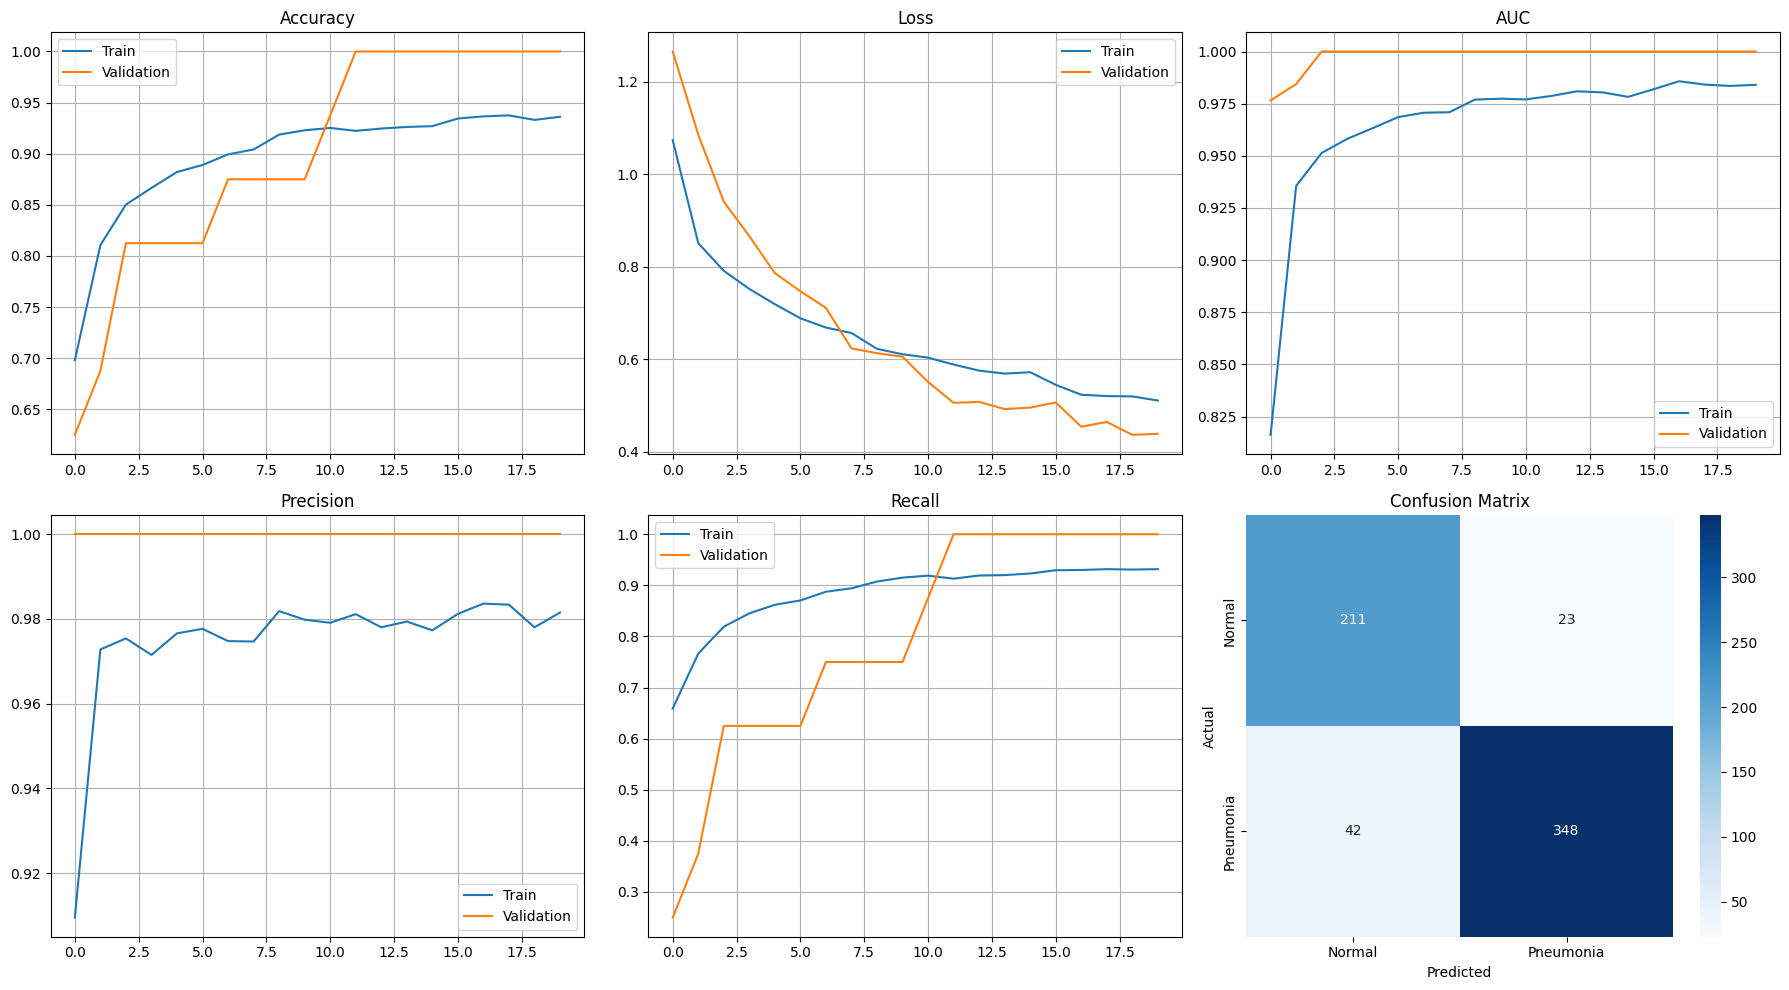

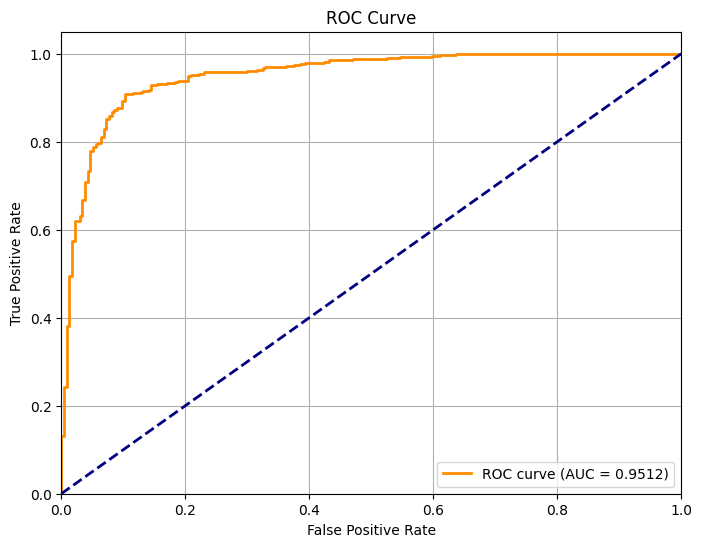


STEP 11: SAVE FILES
✓ Model saved to /kaggle/working/pneumonia_model.keras
✓ Training history saved
✓ Classification report saved
✓ Metrics summary saved
✓ Confusion matrix saved

PROJECT COMPLETE! 

FINAL RESULTS:
✓ Accuracy:  0.8958
✓ Precision: 0.9380
✓ Recall:    0.8923
✓ F1-Score:  0.9146
✓ AUC:       0.9492
✓ ROC AUC:   0.9512

SAVED FILES (in /kaggle/working/):
✓ pneumonia_model.keras
✓ training_history.csv
✓ classification_report.csv
✓ metrics_summary.csv
✓ confusion_matrix.csv

Files in /kaggle/working/:
['.virtual_documents', 'classification_report.csv', 'training_history.csv', 'metrics_summary.csv', 'pneumonia_model.keras', 'confusion_matrix.csv']



In [2]:
# ============================================
# COMPLETE PNEUMONIA DETECTION CODE
# With All Fixes and Proper Saving
# ============================================

import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.utils import class_weight
import warnings
warnings.filterwarnings('ignore')

# ============================================
# 1. ENABLE GPU
# ============================================
print("=" * 60)
print("STEP 1: ENABLE GPU")
print("=" * 60)

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    print("✓ GPU enabled")

# ============================================
# 2. LOAD DATA
# ============================================
print("\n" + "=" * 60)
print("STEP 2: LOAD DATA")
print("=" * 60)

BASE_DIR = '/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray'

TRAIN_DIR = os.path.join(BASE_DIR, 'train')
VAL_DIR = os.path.join(BASE_DIR, 'val')
TEST_DIR = os.path.join(BASE_DIR, 'test')

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    TRAIN_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='binary',
    class_names=['NORMAL', 'PNEUMONIA']
)

val_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    VAL_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='binary',
    class_names=['NORMAL', 'PNEUMONIA']
)

test_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    TEST_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='binary',
    class_names=['NORMAL', 'PNEUMONIA'],
    shuffle=False
)

print("✓ Data loaded!")

# ============================================
# 3. CHECK BALANCE
# ============================================
print("\n" + "=" * 60)
print("STEP 3: CHECK BALANCE")
print("=" * 60)

train_counts = {0: 0, 1: 0}
for _, labels in train_dataset:
    for label in labels.numpy():
        train_counts[int(label[0])] += 1

print(f"Normal: {train_counts[0]} images")
print(f"Pneumonia: {train_counts[1]} images")

total = sum(train_counts.values())
print(f"\nNormal: {train_counts[0]/total*100:.1f}%")
print(f"Pneumonia: {train_counts[1]/total*100:.1f}%")

# ============================================
# 4. DATA AUGMENTATION
# ============================================
print("\n" + "=" * 60)
print("STEP 4: DATA AUGMENTATION")
print("=" * 60)

data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip('horizontal'),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
])

def augment_data(dataset):
    return dataset.map(
        lambda x, y: (data_augmentation(x, training=True), y),
        num_parallel_calls=tf.data.AUTOTUNE
    )

train_dataset = augment_data(train_dataset)
train_dataset = train_dataset.prefetch(tf.data.AUTOTUNE)
val_dataset = val_dataset.prefetch(tf.data.AUTOTUNE)
test_dataset = test_dataset.prefetch(tf.data.AUTOTUNE)

print("✓ Data augmented!")

# ============================================
# 5. CLASS WEIGHTS
# ============================================
print("\n" + "=" * 60)
print("STEP 5: CLASS WEIGHTS")
print("=" * 60)

class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.array([0, 1]),
    y=np.array([0]*train_counts[0] + [1]*train_counts[1])
)

class_weight_dict = {0: class_weights[0], 1: class_weights[1]}
print(f"Class weights: {class_weight_dict}")

# ============================================
# 6. BUILD MODEL
# ============================================
print("\n" + "=" * 60)
print("STEP 6: BUILD MODEL")
print("=" * 60)

from tensorflow.keras.applications import VGG16
from tensorflow.keras import regularizers

base_model = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

base_model.trainable = False

model = tf.keras.Sequential([
    base_model,
    tf.keras.layers.GlobalAveragePooling2D(),
    
    tf.keras.layers.Dense(
        256,
        activation='relu',
        kernel_regularizer=regularizers.l2(0.001)
    ),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.5),
    
    tf.keras.layers.Dense(
        128,
        activation='relu',
        kernel_regularizer=regularizers.l2(0.001)
    ),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.3),
    
    tf.keras.layers.Dense(1, activation='sigmoid')
])

optimizer = tf.keras.optimizers.Adam(learning_rate=0.0001)

model.compile(
    optimizer=optimizer,
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall'),
        tf.keras.metrics.AUC(name='auc')
    ]
)

print("✓ Model built!")

# ============================================
# 7. TRAIN MODEL
# ============================================
print("\n" + "=" * 60)
print("STEP 7: TRAIN MODEL")
print("=" * 60)

callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=0.000001,
        verbose=1
    )
]

history = model.fit(
    train_dataset,
    epochs=20,
    validation_data=val_dataset,
    class_weight=class_weight_dict,
    callbacks=callbacks,
    verbose=1
)

print("✓ Training complete!")

# ============================================
# 8. EVALUATE MODEL
# ============================================
print("\n" + "=" * 60)
print("STEP 8: EVALUATE MODEL")
print("=" * 60)

test_results = model.evaluate(test_dataset)
test_loss = test_results[0]
test_accuracy = test_results[1]
test_precision = test_results[2]
test_recall = test_results[3]
test_auc = test_results[4]

f1_score = 2 * (test_precision * test_recall) / (test_precision + test_recall)

print(f"\nTest Results:")
print(f"  Loss: {test_loss:.4f}")
print(f"  Accuracy: {test_accuracy:.4f}")
print(f"  Precision: {test_precision:.4f}")
print(f"  Recall: {test_recall:.4f}")
print(f"  F1-Score: {f1_score:.4f}")
print(f"  AUC: {test_auc:.4f}")

# ============================================
# 9. PREDICTIONS
# ============================================
print("\n" + "=" * 60)
print("STEP 9: PREDICTIONS")
print("=" * 60)

predictions = model.predict(test_dataset)
predicted_classes = (predictions > 0.5).astype(int)

true_classes = []
for _, labels in test_dataset:
    true_classes.extend(labels.numpy())
true_classes = np.array(true_classes)

print("\nClassification Report:")
print(classification_report(true_classes, predicted_classes, 
                           target_names=['Normal', 'Pneumonia']))

roc_auc = roc_auc_score(true_classes, predictions)
print(f"ROC AUC: {roc_auc:.4f}")

# ============================================
# 10. VISUALIZE RESULTS
# ============================================
print("\n" + "=" * 60)
print("STEP 10: VISUALIZE RESULTS")
print("=" * 60)

# Plot training history
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

axes[0, 0].plot(history.history['accuracy'], label='Train')
axes[0, 0].plot(history.history['val_accuracy'], label='Validation')
axes[0, 0].set_title('Accuracy')
axes[0, 0].legend()
axes[0, 0].grid(True)

axes[0, 1].plot(history.history['loss'], label='Train')
axes[0, 1].plot(history.history['val_loss'], label='Validation')
axes[0, 1].set_title('Loss')
axes[0, 1].legend()
axes[0, 1].grid(True)

axes[0, 2].plot(history.history['auc'], label='Train')
axes[0, 2].plot(history.history['val_auc'], label='Validation')
axes[0, 2].set_title('AUC')
axes[0, 2].legend()
axes[0, 2].grid(True)

axes[1, 0].plot(history.history['precision'], label='Train')
axes[1, 0].plot(history.history['val_precision'], label='Validation')
axes[1, 0].set_title('Precision')
axes[1, 0].legend()
axes[1, 0].grid(True)

axes[1, 1].plot(history.history['recall'], label='Train')
axes[1, 1].plot(history.history['val_recall'], label='Validation')
axes[1, 1].set_title('Recall')
axes[1, 1].legend()
axes[1, 1].grid(True)

cm = confusion_matrix(true_classes, predicted_classes)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1, 2],
            xticklabels=['Normal', 'Pneumonia'],
            yticklabels=['Normal', 'Pneumonia'])
axes[1, 2].set_title('Confusion Matrix')
axes[1, 2].set_xlabel('Predicted')
axes[1, 2].set_ylabel('Actual')

plt.tight_layout()
plt.show()

# ROC Curve
fpr, tpr, _ = roc_curve(true_classes, predictions)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, 
         label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.grid(True)
plt.show()

# ============================================
# 11. SAVE EVERYTHING
# ============================================
print("\n" + "=" * 60)
print("STEP 11: SAVE FILES")
print("=" * 60)

# Create output directory
os.makedirs('/kaggle/working', exist_ok=True)

# Save model
model.save('/kaggle/working/pneumonia_model.keras')
print("✓ Model saved to /kaggle/working/pneumonia_model.keras")

# Save training history
history_df = pd.DataFrame(history.history)
history_df.to_csv('/kaggle/working/training_history.csv', index=False)
print("✓ Training history saved")

# Save classification report
report_dict = classification_report(true_classes, predicted_classes, 
                                    target_names=['Normal', 'Pneumonia'], 
                                    output_dict=True)
report_df = pd.DataFrame(report_dict).transpose()
report_df.to_csv('/kaggle/working/classification_report.csv')
print("✓ Classification report saved")

# Save metrics summary
metrics_summary = {
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC', 'ROC_AUC'],
    'Value': [test_accuracy, test_precision, test_recall, f1_score, test_auc, roc_auc]
}
metrics_df = pd.DataFrame(metrics_summary)
metrics_df.to_csv('/kaggle/working/metrics_summary.csv', index=False)
print("✓ Metrics summary saved")

# Save confusion matrix
cm_df = pd.DataFrame(cm, 
                     columns=['Predicted_Normal', 'Predicted_Pneumonia'],
                     index=['Actual_Normal', 'Actual_Pneumonia'])
cm_df.to_csv('/kaggle/working/confusion_matrix.csv')
print("✓ Confusion matrix saved")

# ============================================
# 12. FINAL SUMMARY
# ============================================
print("\n" + "=" * 60)
print("PROJECT COMPLETE! ")
print("=" * 60)

print(f"""
FINAL RESULTS:
==============
✓ Accuracy:  {test_accuracy:.4f}
✓ Precision: {test_precision:.4f}
✓ Recall:    {test_recall:.4f}
✓ F1-Score:  {f1_score:.4f}
✓ AUC:       {test_auc:.4f}
✓ ROC AUC:   {roc_auc:.4f}

SAVED FILES (in /kaggle/working/):
==================================
✓ pneumonia_model.keras
✓ training_history.csv
✓ classification_report.csv
✓ metrics_summary.csv
✓ confusion_matrix.csv

Files in /kaggle/working/:
{os.listdir('/kaggle/working')}
""")